In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_excel(r"D:\my project\codeit_datascience\data_science\regression\data science\Ecommerce Sales Data.xlsx")
data.head()

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013,6/13/2013,6/17/2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012,2012-11-10 00:00:00,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012,2012-11-10 00:00:00,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Year           9994 non-null   int64  
 3   Order Date     9994 non-null   object 
 4   Ship Date      9994 non-null   object 
 5   Ship Mode      9994 non-null   str    
 6   Customer ID    9994 non-null   str    
 7   Customer Name  9994 non-null   str    
 8   Segment        9994 non-null   str    
 9   Country        9994 non-null   str    
 10  City           9994 non-null   str    
 11  State          9994 non-null   str    
 12  Postal Code    9994 non-null   int64  
 13  Region         9994 non-null   str    
 14  Product ID     9994 non-null   str    
 15  Category       9994 non-null   str    
 16  Sub-Category   9994 non-null   str    
 17  Product Name   9994 non-null   str    
 18  Sales          9994

In [6]:
data.isna().sum()

Row ID           0
Order ID         0
Year             0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
data.Profit.agg(['min','max','mean'])

min    -6599.978000
max     8399.976000
mean      28.656896
Name: Profit, dtype: float64

<Axes: xlabel='Profit', ylabel='Density'>

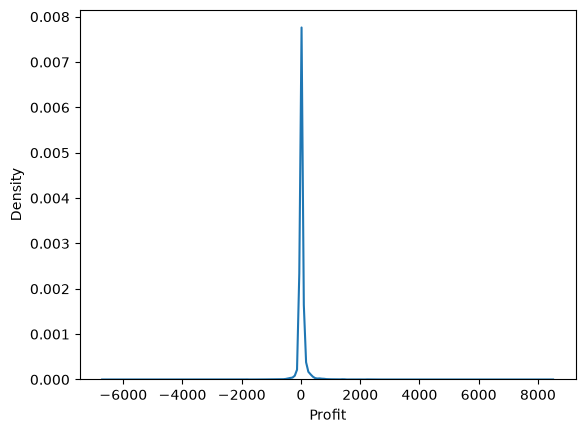

In [8]:
# check outliers in Profit
sns.kdeplot(x='Profit', data=data)

<Axes: ylabel='Profit'>

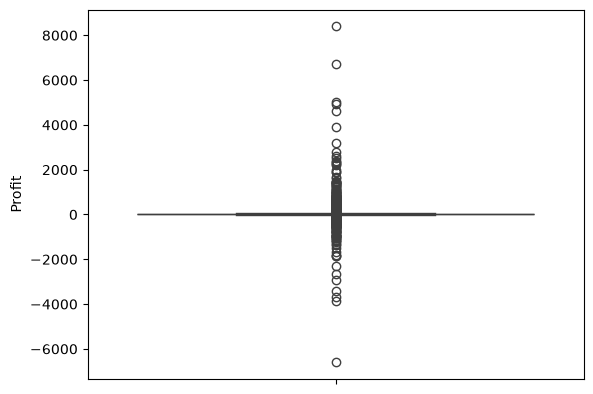

In [9]:
sns.boxplot(y='Profit', data=data)

In [10]:
# check skew()
data.Profit.skew()

np.float64(7.561431562468341)

# Remvoe the Outlier using IQR method

In [11]:
q1 = data.Profit.quantile(0.25)
q1

np.float64(1.72875)

In [12]:
q3 = data.Profit.quantile(0.75)
q3

np.float64(29.364)

In [13]:
iqr = q3 - q1
iqr

np.float64(27.63525)

In [15]:
lb = q1 - 1.5 * iqr
lb

np.float64(-39.724125)

In [16]:
ub = q3 + 1.5 * iqr
ub

np.float64(70.816875)

In [18]:
# get Profit data between lower bond and upper bound
con1 = data.Profit >= lb
con2 = data.Profit <= ub
df_iqr=data[con1 & con2]
df_iqr

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136
2,3,CA-2013-138688,2013,6/13/2013,6/17/2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
4,5,US-2012-108966,2012,2012-11-10 00:00:00,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164
5,6,CA-2011-115812,2011,2011-09-06 00:00:00,6/14/2011,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
6,7,CA-2011-115812,2011,2011-09-06 00:00:00,6/14/2011,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9988,9989,CA-2014-163629,2014,11/18/2014,11/22/2014,Standard Class,RA-19885,Ruben Ausman,Corporate,United States,...,30605,South,TEC-PH-10004006,Technology,Phones,Panasonic KX - TS880B Telephone,206.100,5,0.0,55.6470
9989,9990,CA-2011-110422,2011,1/22/2011,1/24/2011,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932


In [19]:
data.shape

(9994, 22)

In [20]:
df_iqr.shape

(8113, 22)

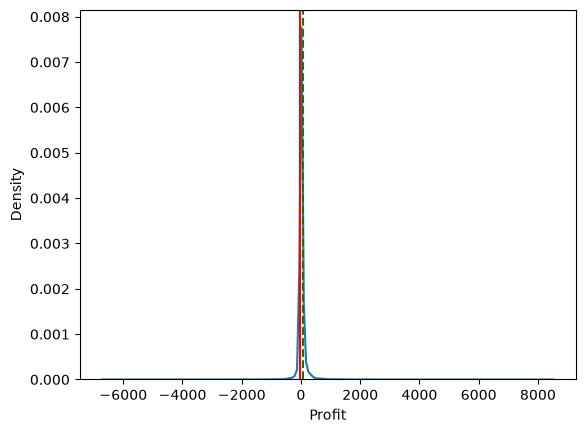

In [24]:
# PLot the ub and lb, on origianl data set
sns.kdeplot(x='Profit', data=data)
plt.axvline(lb, linestyle='-', color='red')
plt.axvline(ub, linestyle='--', color='green')


In [26]:
data.Profit.agg(['min','max','mean'])

min    -6599.978000
max     8399.976000
mean      28.656896
Name: Profit, dtype: float64

In [27]:
df_iqr.Profit.agg(['min','max','mean'])

min    -39.637000
max     70.722000
mean    11.604086
Name: Profit, dtype: float64

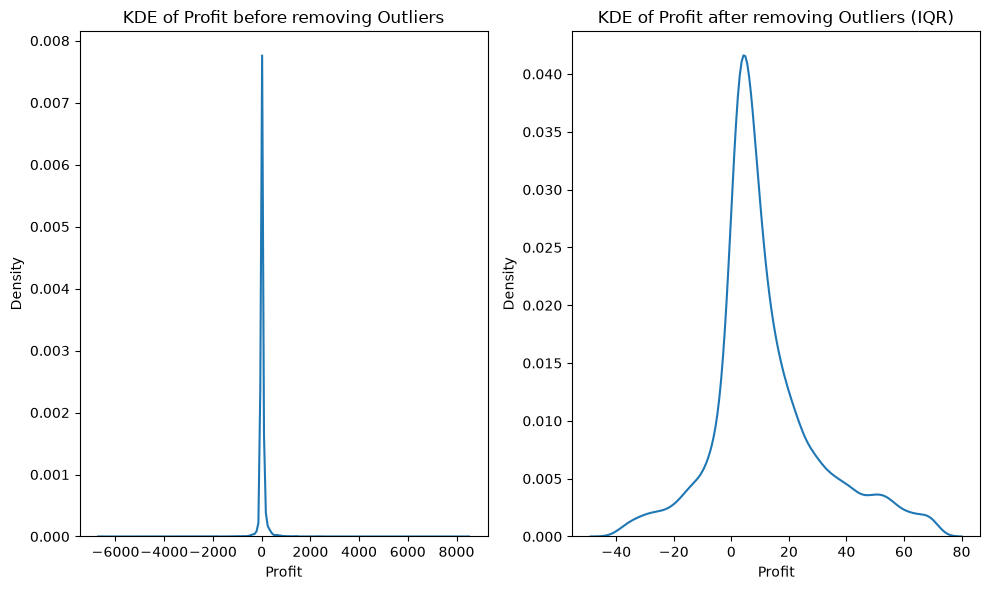

In [25]:
# compare 'data' set and df_iqr 'data set' in kde plot
fig, axes = plt.subplots(1,2, figsize=(10,6))
sns.kdeplot(x='Profit', data=data, ax=axes[0])
axes[0].set_title("KDE of Profit before removing Outliers")
sns.kdeplot(x='Profit', data=df_iqr, ax=axes[1])
axes[1].set_title("KDE of Profit after removing Outliers (IQR)")
plt.tight_layout()
plt.show()

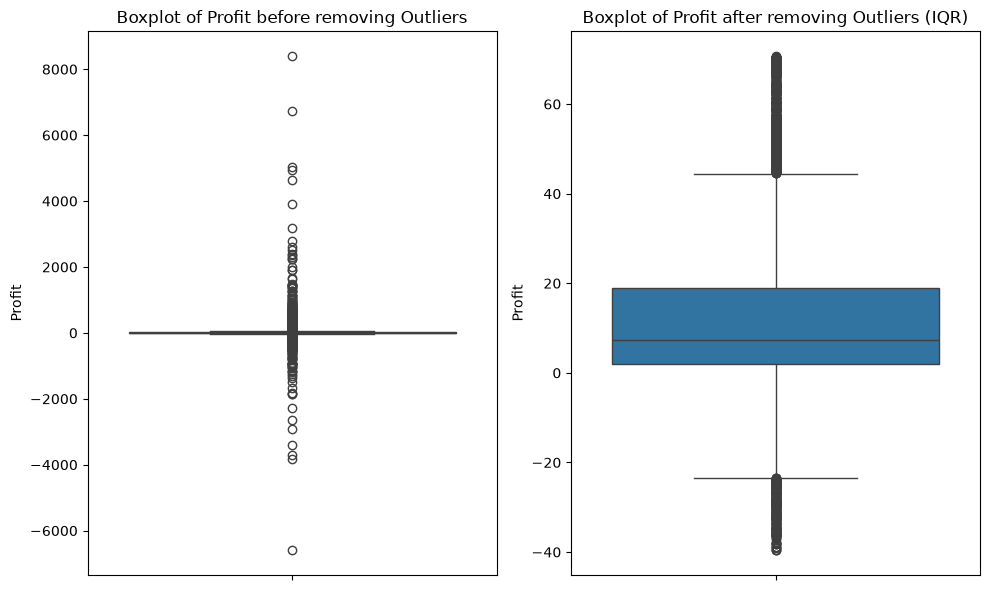

In [29]:
# Campare 'data' and 'df_iqr' in boxplot()
fig, axes = plt.subplots(1,2,figsize=(10,6))
sns.boxplot(y='Profit', data=data, ax=axes[0])
axes[0].set_title("Boxplot of Profit before removing Outliers")
sns.boxplot(y='Profit', data=df_iqr, ax=axes[1])
axes[1].set_title("Boxplot of Profit after removing Outliers (IQR)")
plt.tight_layout()
plt.show()

In [30]:
# Remove Outliers using Zscore method
from scipy import stats

In [31]:
data['zscore'] = stats.zscore(data.Profit)

In [32]:
data.head(2)

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,zscore
0,1,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,0.056593
1,2,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,0.815054


In [33]:
# we select zscore value between 3 to -3 only
# make all zscore value abs()
data['zscore'] = abs(data.zscore)

In [35]:
data.zscore

0       0.056593
1       0.815054
2       0.093002
3       1.757484
4       0.111593
          ...   
9989    0.104821
9990    0.055598
9991    0.039546
9992    0.065473
9993    0.189078
Name: zscore, Length: 9994, dtype: float64

In [36]:
# select the value below <=3 only from zscore value
df_zscore = data[data['zscore']<=3]
df_zscore

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,zscore
0,1,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.056593
1,2,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.815054
2,3,CA-2013-138688,2013,6/13/2013,6/17/2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.093002
3,4,US-2012-108966,2012,2012-11-10 00:00:00,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,1.757484
4,5,US-2012-108966,2012,2012-11-10 00:00:00,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.111593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2011-110422,2011,1/22/2011,1/24/2011,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,...,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,0.104821
9990,9991,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,0.055598
9991,9992,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,0.039546
9992,9993,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,0.065473


In [39]:
df_zscore.Profit.agg(['min','max','mean'])

min    -653.283400
max     726.561900
mean     23.161187
Name: Profit, dtype: float64

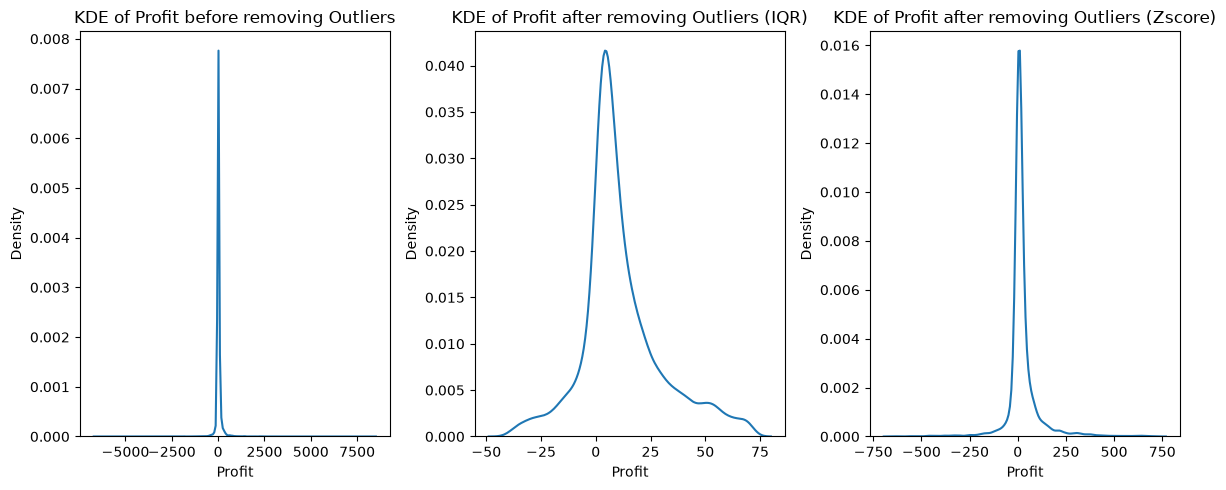

In [40]:
# compare 'data' set,  df_iqr 'data set', df_zscore  in kde plot
fig, axes = plt.subplots(1,3, figsize=(12,5))
sns.kdeplot(x='Profit', data=data, ax=axes[0])
axes[0].set_title("KDE of Profit before removing Outliers")
sns.kdeplot(x='Profit', data=df_iqr, ax=axes[1])
axes[1].set_title("KDE of Profit after removing Outliers (IQR)")
sns.kdeplot(x='Profit', data=df_zscore, ax=axes[2])
axes[2].set_title("KDE of Profit after removing Outliers (Zscore)")
plt.tight_layout()
plt.show()


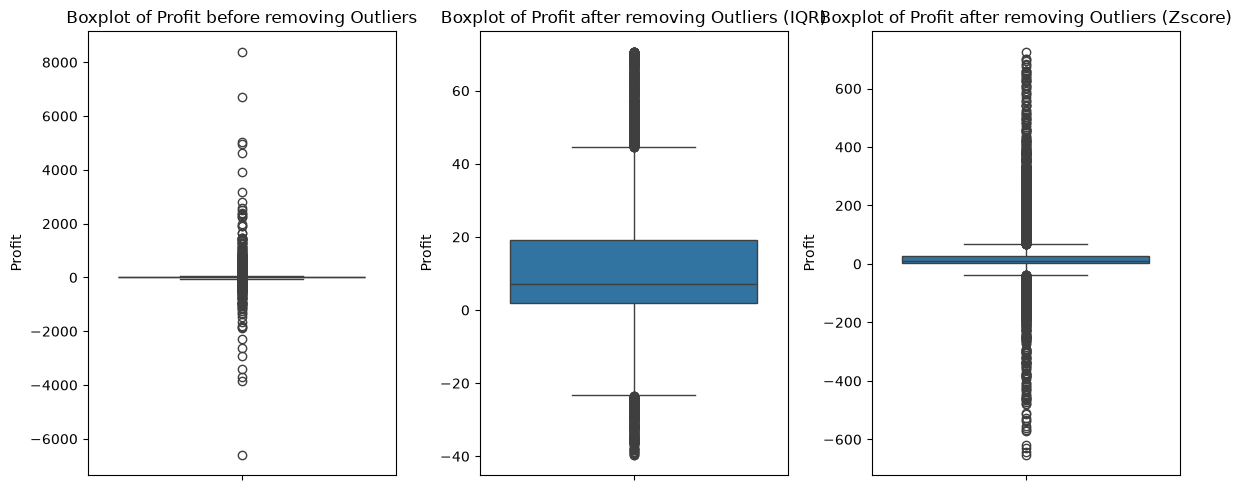

In [41]:
# Campare 'data' and 'df_iqr', 'df_zscore', in boxplot()
fig, axes = plt.subplots(1,3,figsize=(12,5))
sns.boxplot(y='Profit', data=data, ax=axes[0])
axes[0].set_title("Boxplot of Profit before removing Outliers")
sns.boxplot(y='Profit', data=df_iqr, ax=axes[1])
axes[1].set_title("Boxplot of Profit after removing Outliers (IQR)")
sns.boxplot(y='Profit', data=df_zscore, ax=axes[2])
axes[2].set_title("Boxplot of Profit after removing Outliers (Zscore)")
plt.tight_layout()
plt.show()

In [42]:
# Remove outliers using std and mean method
std = data.Profit.std()
std

np.float64(234.2601076909573)

In [44]:
m = data.Profit.mean()
m

np.float64(28.65689630778467)

In [45]:
upper_limit = m + 3 * std
upper_limit

np.float64(731.4372193806566)

In [46]:
lower_limit = m - 3 * std
lower_limit

np.float64(-674.1234267650873)

In [47]:
c1 = data.Profit >= lower_limit
c2 = data.Profit <= upper_limit
df_std_mean = data[c1 & c2]
df_std_mean

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,zscore
0,1,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.056593
1,2,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.815054
2,3,CA-2013-138688,2013,6/13/2013,6/17/2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.093002
3,4,US-2012-108966,2012,2012-11-10 00:00:00,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,1.757484
4,5,US-2012-108966,2012,2012-11-10 00:00:00,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.111593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2011-110422,2011,1/22/2011,1/24/2011,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,...,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,0.104821
9990,9991,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,0.055598
9991,9992,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,0.039546
9992,9993,CA-2014-121258,2014,2/27/2014,2014-04-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,0.065473


In [48]:
data.shape

(9994, 23)

In [49]:
df_std_mean.shape

(9887, 23)

In [50]:
data.Profit.agg(['mean','std'])

mean     28.656896
std     234.260108
Name: Profit, dtype: float64

In [53]:
df_std_mean.Profit.agg(['mean','std','min','max'])

mean     23.161187
std      88.466917
min    -653.283400
max     726.561900
Name: Profit, dtype: float64

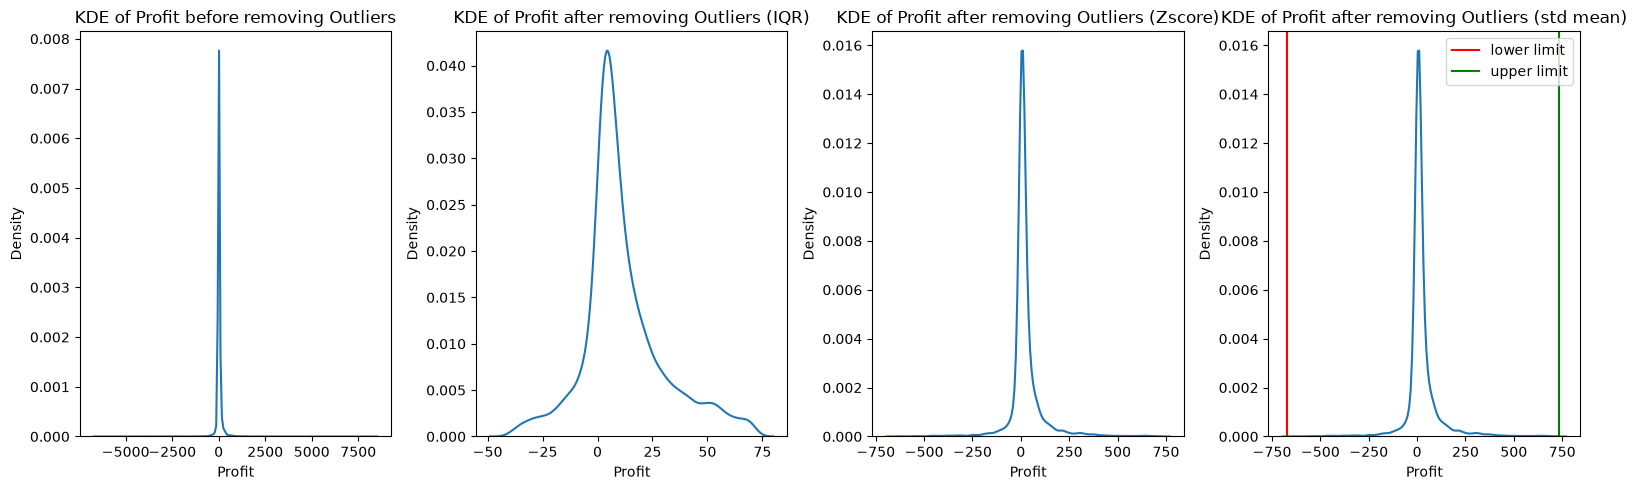

In [55]:
# # compare 'data' set,  df_iqr 'data set', df_zscore, df_std_mean  in kde plot
fig, axes = plt.subplots(1,4, figsize=(16,5))
sns.kdeplot(x='Profit', data=data, ax=axes[0])
axes[0].set_title("KDE of Profit before removing Outliers")
sns.kdeplot(x='Profit', data=df_iqr, ax=axes[1])
axes[1].set_title("KDE of Profit after removing Outliers (IQR)")
sns.kdeplot(x='Profit', data=df_zscore, ax=axes[2])
axes[2].set_title("KDE of Profit after removing Outliers (Zscore)")
sns.kdeplot(x='Profit', data=df_std_mean, ax=axes[3])
axes[3].set_title("KDE of Profit after removing Outliers (std mean)")
axes[3].axvline(lower_limit, color='red', label='lower limit')
axes[3].axvline(upper_limit, color='green', label='upper limit')
plt.tight_layout()
plt.legend()
plt.show()

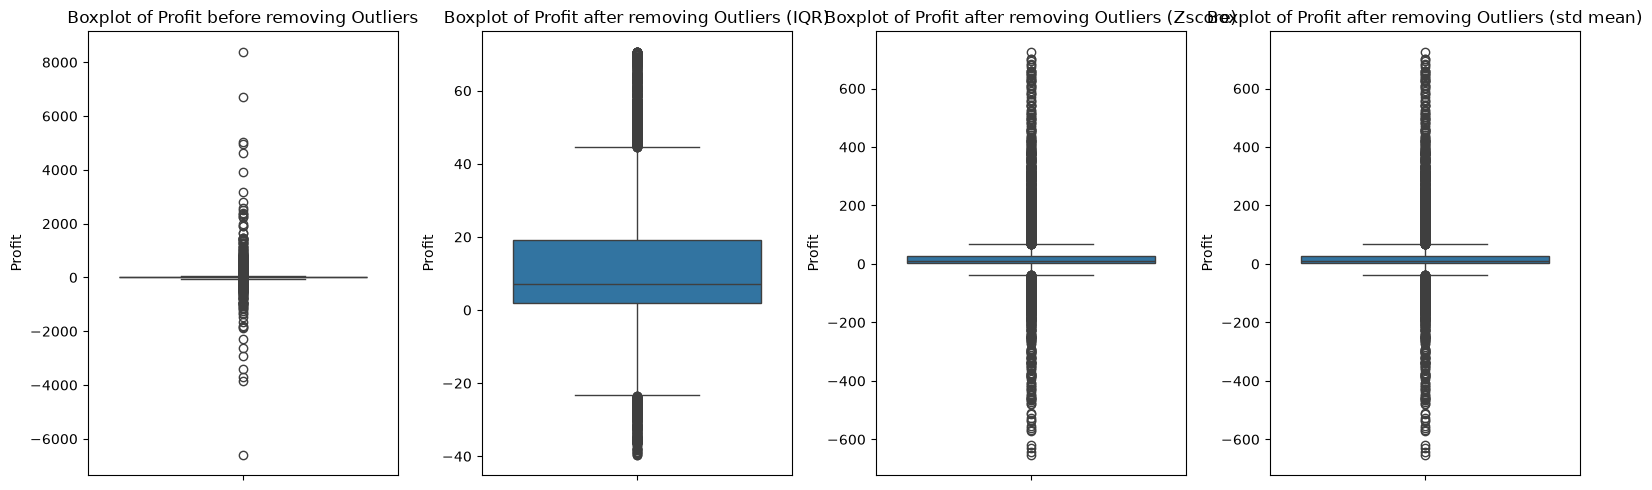

In [56]:
# Campare 'data' and 'df_iqr', 'df_zscore', 'df_std_mean' in boxplot()
fig, axes = plt.subplots(1,4,figsize=(16,5))
sns.boxplot(y='Profit', data=data, ax=axes[0])
axes[0].set_title("Boxplot of Profit before removing Outliers")
sns.boxplot(y='Profit', data=df_iqr, ax=axes[1])
axes[1].set_title("Boxplot of Profit after removing Outliers (IQR)")
sns.boxplot(y='Profit', data=df_zscore, ax=axes[2])
axes[2].set_title("Boxplot of Profit after removing Outliers (Zscore)")
sns.boxplot(y='Profit', data=df_std_mean, ax=axes[3])
axes[3].set_title("Boxplot of Profit after removing Outliers (std mean)")
plt.tight_layout()
plt.show()

In [57]:
# check the skew() for all
skew_all = data.Profit.skew()
skew_iqr = df_iqr.Profit.skew()
skew_zscore = df_zscore.Profit.skew()
skew_std_mean = df_std_mean.Profit.skew()

In [58]:
print(f"Original data skew : {skew_all}")
print(f"IQR method data skew : {skew_iqr}")
print(f"Zscore method data skew : {skew_zscore}")
print(f"Std mean method data skew : {skew_std_mean}")

Original data skew : 7.561431562468341
IQR method data skew : 0.765668507343356
Zscore method data skew : 1.400896871108375
Std mean method data skew : 1.400896871108375


In [59]:
# from the above skew from all method, IQR has less skew, near to zero. So, we selct IQR method data set for analysis

In [60]:
# use scatter plot for all dataset

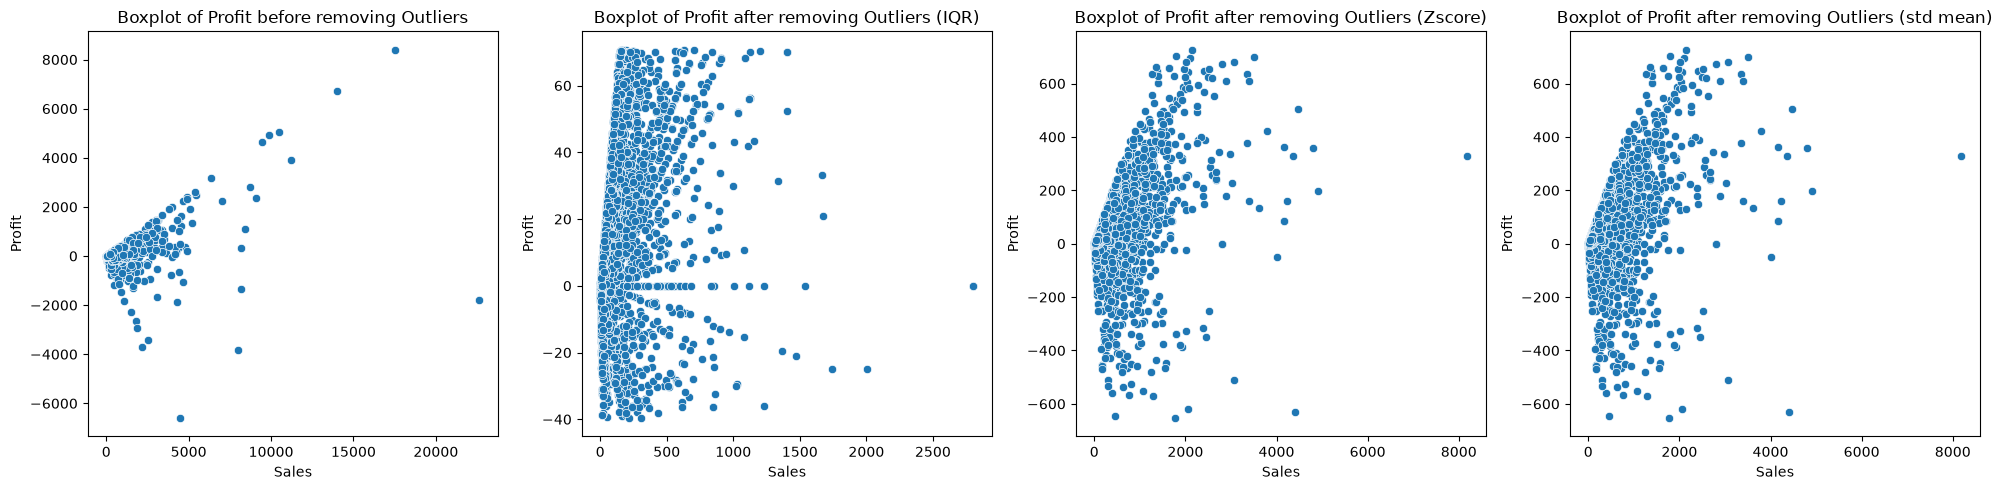

In [62]:
# Campare 'data' and 'df_iqr', 'df_zscore', 'df_std_mean' in scatterplot()
fig, axes = plt.subplots(1,4,figsize=(20,5))
sns.scatterplot(y='Profit', x='Sales', data=data, ax=axes[0])
axes[0].set_title("Boxplot of Profit before removing Outliers")
sns.scatterplot(y='Profit',x='Sales', data=df_iqr, ax=axes[1])
axes[1].set_title("Boxplot of Profit after removing Outliers (IQR)")
sns.scatterplot(y='Profit',x='Sales', data=df_zscore, ax=axes[2])
axes[2].set_title("Boxplot of Profit after removing Outliers (Zscore)")
sns.scatterplot(y='Profit', x='Sales',data=df_std_mean, ax=axes[3])
axes[3].set_title("Boxplot of Profit after removing Outliers (std mean)")
plt.tight_layout()
plt.show()